<a href="https://colab.research.google.com/github/shumailas709/Data-Analytic-Portfolio-/blob/main/CreditCard_FraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Project 7 - Credit Card Fraud Detection
# Author: Shumaila Shaikh

from google.colab import files
uploaded = files.upload()


Saving creditcard.csv to creditcard.csv


In [7]:
# ================================
# Project 7 - Fraud Detection
# Dataset: Credit Card Fraud
# Source: Kaggle (ULB)
# ================================

df = pd.read_csv('creditcard.csv')
print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)


✅ Dataset loaded successfully!
Shape: (284807, 31)


In [8]:
# ================================
# Step 2 - Data Exploration (EDA)
# ================================

# Basic info
print("📊 First 5 rows:")
print(df.head())

print("\n📋 Dataset Info:")
print(df.info())

print("\n❓ Missing Values:")
print(df.isnull().sum().sum())

print("\n🔍 Fraud vs Genuine:")
print(df['Class'].value_counts())
print(f"\nFraud %: {round(df['Class'].value_counts()[1]/len(df)*100, 3)}%")


📊 First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26     

/tmp/ipykernel_1384/2653901009.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['steelblue','crimson'])


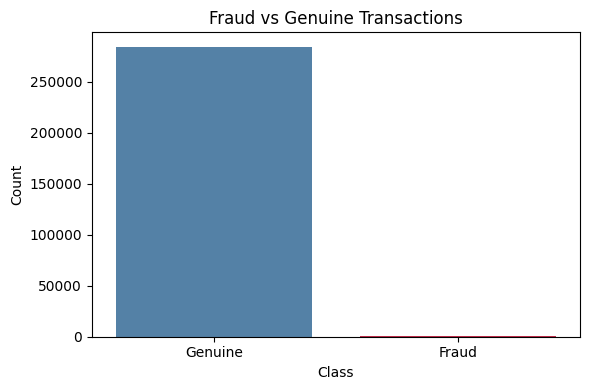

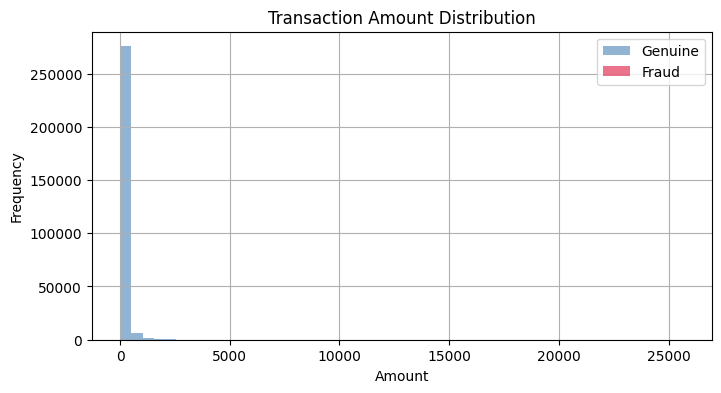

✅ Plots ready!


In [9]:
# ================================
# Step 3 - Visualizations
# ================================

# Plot 1: Fraud vs Genuine count
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['steelblue','crimson'])
plt.title('Fraud vs Genuine Transactions')
plt.xticks([0,1], ['Genuine', 'Fraud'])
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Plot 2: Transaction Amount
plt.figure(figsize=(8,4))
df[df['Class']==0]['Amount'].hist(bins=50, alpha=0.6, label='Genuine', color='steelblue')
df[df['Class']==1]['Amount'].hist(bins=50, alpha=0.6, label='Fraud', color='crimson')
plt.legend()
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

print("✅ Plots ready!")


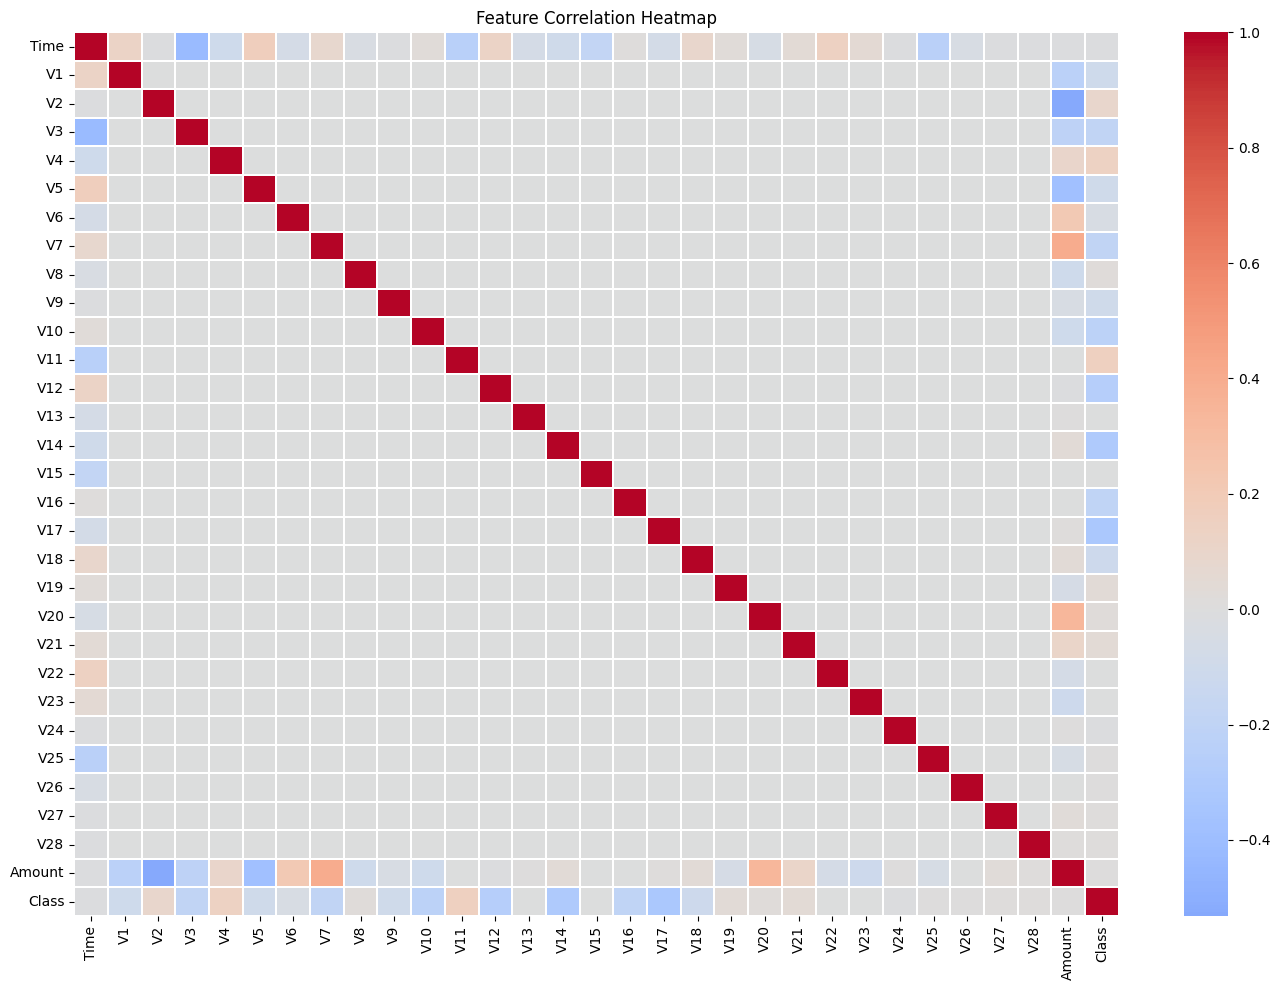

✅ Heatmap ready!


In [10]:
# ================================
# Step 4 - Correlation Heatmap
# ================================

plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

print("✅ Heatmap ready!")


In [11]:
# ================================
# Step 5 - Preprocessing
# ================================

# Features aur target alag karo
X = df.drop('Class', axis=1)
y = df['Class']

# Amount aur Time scale karo
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time']   = scaler.fit_transform(X[['Time']])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE - class balance karo
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("✅ Preprocessing done!")
print(f"Train size: {X_train.shape[0]}")
print(f"After SMOTE - Genuine: {sum(y_train_bal==0)} | Fraud: {sum(y_train_bal==1)}")


✅ Preprocessing done!
Train size: 227845
After SMOTE - Genuine: 227451 | Fraud: 227451


In [13]:
# ================================
# Step 6 - Model Training
# ================================

# Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_bal, y_train_bal)
print("Done!")

# Decision Tree
print("Training Decision Tree...")
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_bal, y_train_bal)
print("Done!")

# Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)
print("Done!")

print("\nAll models trained successfully!")


Training Logistic Regression...
Done!
Training Decision Tree...
Done!
Training Random Forest...
Done!

All models trained successfully!


In [14]:
# ================================
# Step 7 - Model Evaluation
# ================================

models = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf
}

for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print('='*40)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    print(classification_report(y_test, y_pred, target_names=['Genuine','Fraud']))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")



Model: Logistic Regression
              precision    recall  f1-score   support

     Genuine       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC Score: 0.9698

Model: Decision Tree
              precision    recall  f1-score   support

     Genuine       1.00      0.95      0.97     56864
       Fraud       0.03      0.90      0.06        98

    accuracy                           0.95     56962
   macro avg       0.51      0.92      0.52     56962
weighted avg       1.00      0.95      0.97     56962

ROC-AUC Score: 0.9522

Model: Random Forest
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56864
       Fraud       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg

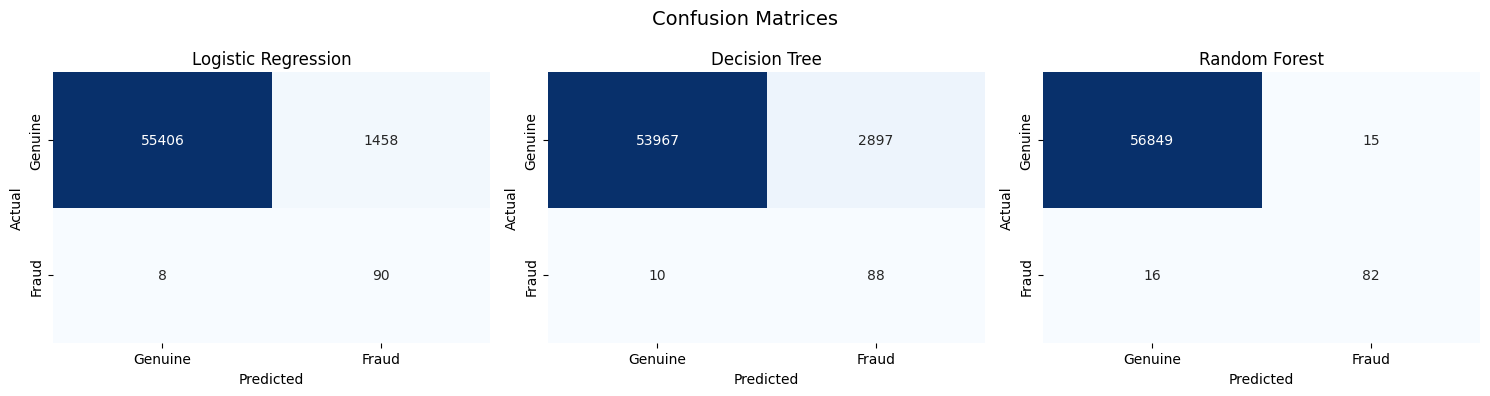

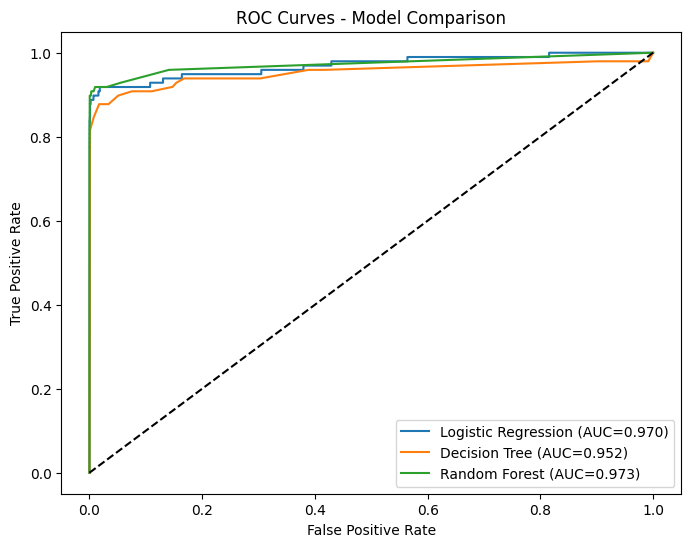

Project Complete!


In [15]:
# ================================
# Step 8 - Final Visualizations
# ================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', cbar=False,
                xticklabels=['Genuine','Fraud'],
                yticklabels=['Genuine','Fraud'])
    ax.set_title(f'{name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend()
plt.show()

print("Project Complete!")
